In [4]:
from elpv_dataset.utils import load_dataset

images, proba, types = load_dataset()

print(images.shape)
print(proba[:10])
print(types[:10])

(2624, 300, 300)
[1. 1. 1. 0. 1. 1. 1. 1. 0. 1.]
['mono' 'mono' 'mono' 'mono' 'mono' 'mono' 'mono' 'mono' 'mono' 'mono']


In [5]:
import numpy as np

unique_proba, counts = np.unique(proba, return_counts=True)
for p, c in zip(unique_proba, counts):
    print(f"probability={p}: {c} images")

unique_types, type_counts = np.unique(types, return_counts=True)
for t, c in zip(unique_types, type_counts):
    print(f"{t}: {c} images")

probability=0.0: 1508 images
probability=0.3333333333333333: 295 images
probability=0.6666666666666666: 106 images
probability=1.0: 715 images
mono: 1074 images
poly: 1550 images


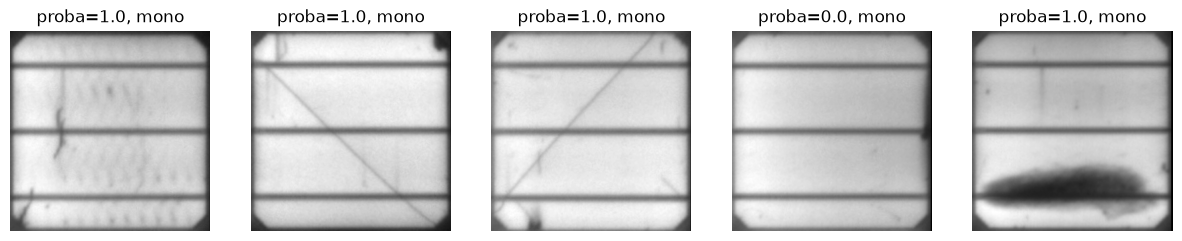

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"proba={proba[i]}, {types[i]}")
    ax.axis('off')
plt.show()

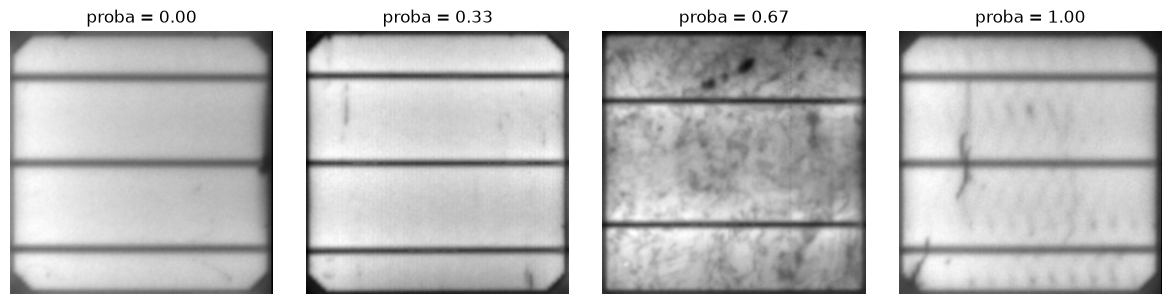

In [7]:
import matplotlib.pyplot as plt
import numpy as np

probability_levels = [0.0, 1/3, 2/3, 1.0]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, p in zip(axes, probability_levels):
    indices = np.where(np.isclose(proba, p))[0]
    idx = indices[0]

    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"proba = {p:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Convert probability values into 4 defect classes

class_names = {
    0.0: "Healthy",
    1/3: "Mild",
    2/3: "Moderate",
    1.0: "Severe"
}

labels = np.array([class_names[p] for p in proba])

unique_labels, label_counts = np.unique(labels, return_counts=True)

for label, count in zip(unique_labels, label_counts):
    print(f"{label}: {count} images")

Healthy: 1508 images
Mild: 295 images
Moderate: 106 images
Severe: 715 images
